# Predictive Employee Churn

Predict employee departure in a public HR benchmark and describe which input features the model relies on.

There are no employee identifiers, observation dates, or defined prediction horizon. Random benchmark holdouts do not establish future-employer performance. Feature importance and department rates are associations, not causal evidence or grounds for individual employment decisions.

## Reproduce the workflow

Install `requirements-dev.txt` into your Python environment, then run this notebook from the repository. No database, Databricks, S3 mount, or credentials are required.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown, Image
from fetch_data import fetch
from analysis import run, ROOT
fetch()

Verified existing input: data/hr.csv


## Source and input checks

14,999 HR benchmark rows with satisfaction, evaluation, workload, tenure, accidents, promotion, department, salary, and `left` labels. This matches the schema and row count used in the historical notebook. There are 3,008 exact duplicate rows; deduplication leaves 11,991. Dataset source provenance is limited: the file is a public teaching benchmark, not verified records of a named employer. A different IBM HR ZIP was present locally, but its schema did not match this project; it was left untouched.

In [2]:
data = pd.read_csv(ROOT / 'data/hr.csv')
print('Rows and columns:', data.shape)
display(data.head())
display(data['left'].value_counts().rename('label_count'))

Rows and columns: (14999, 10)


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


left
0    11428
1     3571
Name: label_count, dtype: int64

## Evaluation design

Deduplicate before stratified train/validation/test splitting. Fit imputation, scaling, and one-hot encoding inside each training pipeline. Compare logistic regression and a bounded random forest against a prevalence baseline. Select on validation average precision, then select the validation F1 threshold. Compute feature importance on validation and descriptive department rates on training only.

In [3]:
summary = run()
display(pd.read_csv(ROOT / 'results/metrics.csv'))
print('Validation-selected model:', summary['selected_model'])

,model,split,average_precision,roc_auc,log_loss,brier_score,accuracy,precision,recall,f1,threshold,tn,fp,fn,tp,alerts,positive_rate,rows
0,baseline,validation,0.165972,0.500000,0.449441,0.138425,0.834028,0.000000,0.000000,0.000000,0.500000,2000,0,398,0,0,0.165972,2398
1,logistic_regression,validation,0.421351,0.829786,0.355252,0.113076,0.799416,0.438519,0.743719,0.551724,0.209080,1621,379,102,296,675,0.165972,2398
2,random_forest,validation,0.967099,0.985094,0.079953,0.017051,0.983736,0.978667,0.922111,0.949547,0.488409,1992,8,31,367,375,0.165972,2398
3,baseline,test,0.165902,0.500000,0.449329,0.138379,0.834098,0.000000,0.000000,0.000000,0.500000,2001,0,398,0,0,0.165902,2399
4,logistic_regression,test,0.397451,0.816568,0.365800,0.116538,0.792830,0.424196,0.695980,0.527117,0.209080,1625,376,121,277,653,0.165902,2399
5,random_forest,test,0.959545,0.980466,0.085167,0.017644,0.980825,0.978261,0.904523,0.939948,0.488409,1993,8,38,360,368,0.165902,2399


Validation-selected model: random_forest


## Held-out results

The model and decision threshold were selected before looking at these test outcomes. A positive prediction is defined by the target label in the data documentation.

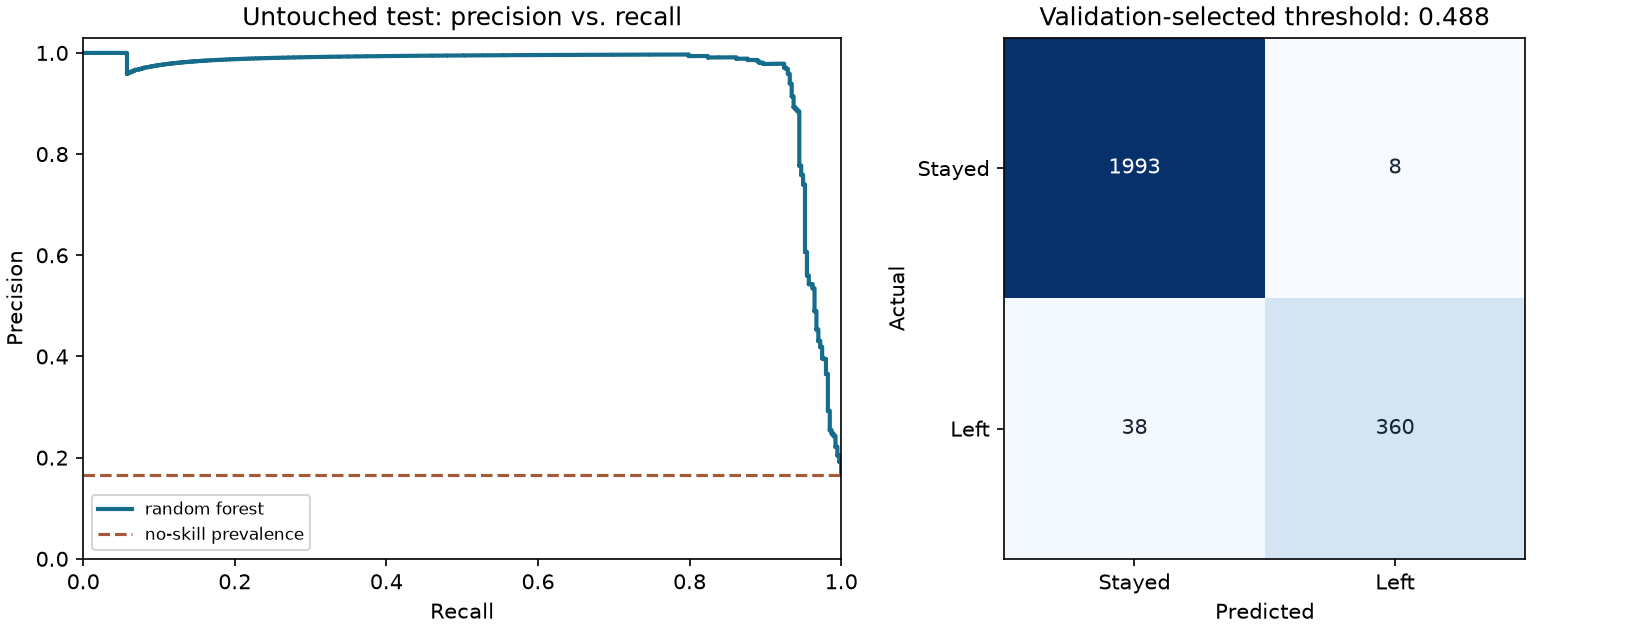

# Predictive Employee Churn — reproducible results

Predict `left=1` (employee departure) from the 14,999-row public HR Analytics benchmark. Exact duplicate records and conflicting duplicate labels are removed before splitting. The model uses the original operational features, with numeric imputation, scaling, and categorical encoding inside a pipeline.

## Evaluation design

Seed 42. Training, validation, and test row counts: 7,194,
2,398, 2,399.
Preprocessing is fitted inside the training pipeline. Model selection uses validation
average_precision; the decision threshold maximizes validation F1.
The selected model is **random_forest**. No tuning uses the test labels.

## Untouched test results

| Measure | Selected model | Constant-prevalence baseline |
|---|---:|---:|
| Average precision | 0.9595 | 0.1659 |
| ROC AUC | 0.9805 | 0.5000 |
| Log loss (lower is better) | 0.0852 | 0.4493 |
| Brier score (lower is better) | 0.0176 | 0.1384 |
| Precision | 0.9783 | 0.0000 |
| Recall | 0.9045 | 0.0000 |
| F1 | 0.9399 | 0.0000 |
| Accuracy | 0.9808 | 0.8341 |

At threshold **0.4884**, the model produces **368** positive flags:
**360** true positives and **8** false positives.
It misses **38** positives; **1,993** negatives are correctly rejected.
Test positive prevalence is **16.59%**, across 2,399 rows.

![Precision–recall curve and confusion matrix](evaluation.png)

## Interpretation and limits

The random forest and logistic regression are compared with a constant-prevalence baseline. `feature_importance.csv` measures permutation importance on validation data; it is association, not proof of a cause. `department_summary.csv` is descriptive training-only analysis. This public benchmark has limited source provenance and no employee identifiers or observation dates, so a random holdout cannot prove future-company performance or a specific prediction horizon. It cannot establish that workload causes departures, or that intervening on a feature will retain an employee. Results support an educational analytics demonstration; external and temporal validation would be needed for workplace use.

See [all candidate metrics](metrics.csv), [auditable test predictions](predictions.csv),
[split assignments](splits.csv), and [run metadata, input hash, and package versions](metrics.json).
Numbers here are generated by the script, not copied from the historical notebook.


In [4]:
display(Image(filename=str(ROOT / 'results/evaluation.png')))
display(Markdown((ROOT / 'results/REPORT.md').read_text()))

## Auditable outputs

The scores below are held-out predictions, not training predictions.

In [5]:
display(pd.read_csv(ROOT / 'results/predictions.csv').head(10))

,row_id,actual,baseline_score,logistic_regression_score,random_forest_score,predicted
0,2967,0,0.166111,0.415074,0.103838,0
1,11099,0,0.166111,0.007858,0.010476,0
2,9036,0,0.166111,0.014962,0.020729,0
3,7556,0,0.166111,0.061096,0.001188,0
4,5125,0,0.166111,0.159404,0.002470,0
5,7743,0,0.166111,0.111866,0.103318,0
6,1860,1,0.166111,0.486394,0.932341,1
7,8054,0,0.166111,0.156007,0.011383,0
8,11743,0,0.166111,0.066739,0.002322,0
9,8962,0,0.166111,0.407463,0.092374,0


## Inference on new rows

Use the saved preprocessing pipeline and the validation-selected threshold. These three example rows come from the public input; they illustrate the interface and do not provide a new performance estimate.

In [6]:
from predict import predict
display(predict(ROOT / 'examples/new_rows.csv', ROOT / 'results/model.joblib', ROOT / 'results/new_predictions.csv'))

,row_id,positive_score,predicted
0,0,0.991466,1
1,1,0.881830,1
2,2,0.995944,1


## Task-specific checks

These outputs expose model errors, interpretation, or ranking performance instead of relying on a single headline score.

In [7]:
print('feature_importance.csv')
display(pd.read_csv(ROOT / 'results/feature_importance.csv').head(10))
print('department_summary.csv')
display(pd.read_csv(ROOT / 'results/department_summary.csv').head(10))

feature_importance.csv

,feature,validation_ap_decrease,repeat_std
0,satisfaction_level,0.342198,0.015094
1,number_project,0.123105,0.002570
2,time_spend_company,0.102112,0.007109
3,average_montly_hours,0.077486,0.001006
4,last_evaluation,0.042642,0.010726
5,salary,0.002365,0.000590
6,department,0.001474,0.000734
7,Work_accident,0.001288,0.000550
8,promotion_last_5years,-0.000008,0.000014


department_summary.csv


,department,count,attrition_rate
0,IT,583,0.169811
1,RandD,432,0.108796
2,accounting,369,0.178862
3,hr,353,0.192635
4,management,243,0.106996
5,marketing,397,0.173804
6,product_mng,421,0.144893
7,sales,1924,0.178274
8,support,1105,0.160181
9,technical,1367,0.174835


## What these results establish

There are no employee identifiers, observation dates, or defined prediction horizon. Random benchmark holdouts do not establish future-employer performance. Feature importance and department rates are associations, not causal evidence or grounds for individual employment decisions.

See `data/provenance.json` and `results/metrics.json` for provenance and run settings. The numbers shown here come from this execution.